In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import os


In [2]:
file_path = "Airbnb.xlsx"   # replace with your actual filename
df = pd.read_excel(file_path)
print(df.head())


        id                                              NAME      host id  \
0  1001254                Clean & quiet apt home by the park  80014485718   
1  1002102                             Skylit Midtown Castle  52335172823   
2  1002403               THE VILLAGE OF HARLEM....NEW YORK !  78829239556   
3  1002755                                               NaN  85098326012   
4  1003689  Entire Apt: Spacious Studio/Loft by central park  92037596077   

  host_identity_verified host name neighbourhood group neighbourhood  \
0            unconfirmed  Madaline            Brooklyn    Kensington   
1               verified     Jenna           Manhattan       Midtown   
2                    NaN     Elise           Manhattan        Harlem   
3            unconfirmed     Garry            Brooklyn  Clinton Hill   
4               verified    Lyndon           Manhattan   East Harlem   

        lat      long        country  ... service fee  minimum nights  \
0  40.64749 -73.97237  United S

In [3]:
def find_price_column(df):
    for c in df.columns:
        if any(k in c.lower() for k in ["price", "rate", "cost", "rent", "amount"]):
            return c
    for c in df.columns:
        sample = df[c].astype(str).dropna().head(40)
        if any(("$" in s) or ("₹" in s) or ("," in s and any(ch.isdigit() for ch in s)) for s in sample):
            return c
    return None

In [4]:
price_col = find_price_column(df)
print("\nDetected price column:", price_col)

def to_numeric_price(series):
    s = series.astype(str).str.replace(r"[^\d\.\-]", "", regex=True)
    s = s.replace({"": np.nan, "nan": np.nan})
    return pd.to_numeric(s, errors="coerce")

if price_col is not None:
    df["price_clean"] = to_numeric_price(df[price_col])
    print("\nPrice stats:")
    print(df["price_clean"].describe())
else:
    print("\n⚠️ No price column detected. ML step will be skipped.")


Detected price column: price

Price stats:
count    102352.000000
mean        625.293536
std         331.671614
min          50.000000
25%         340.000000
50%         624.000000
75%         913.000000
max        1200.000000
Name: price_clean, dtype: float64


In [5]:
print("\nSummary of numeric columns:")
print(df.describe().transpose())

print("\nTop 10 columns by missing values:")
print(df.isnull().sum().sort_values(ascending=False).head(10))

before = len(df)
df = df.drop_duplicates()
print(f"\nRemoved {before - len(df)} duplicate rows. Remaining: {len(df)}")



Summary of numeric columns:
                                   count                           mean  \
id                              102599.0                 29146234.52213   
host id                         102599.0             49254111474.328667   
lat                             102591.0                      40.728094   
long                            102591.0                     -73.949644   
instant_bookable                102494.0                       0.497785   
Construction year               102385.0                    2012.487464   
price                           102352.0                     625.293536   
service fee                     102326.0                     125.026924   
minimum nights                  102190.0                       8.135845   
number of reviews               102416.0                      27.483743   
last review                        86706  2019-06-12 03:40:52.065601024   
reviews per month                86720.0                       1.374022

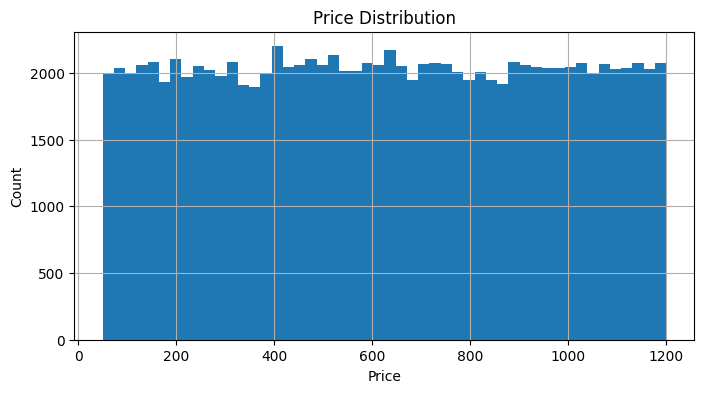


Top locations by count:
neighbourhood group
Manhattan        43557
Brooklyn         41630
Queens           13197
Bronx             2694
Staten Island      949
brookln              1
manhatan             1
Name: count, dtype: int64


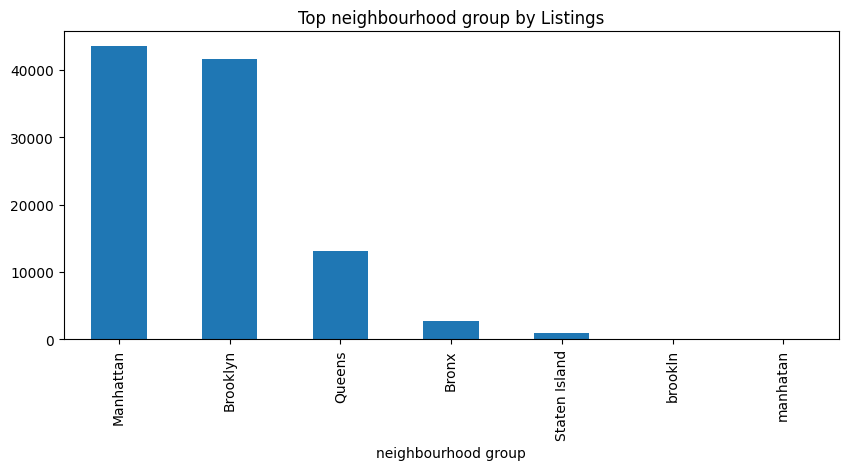

In [6]:
if "price_clean" in df.columns:
    plt.figure(figsize=(8,4))
    df["price_clean"].dropna().hist(bins=50)
    plt.title("Price Distribution")
    plt.xlabel("Price")
    plt.ylabel("Count")
    plt.show()

# Location column check
location_cols = [c for c in df.columns if any(k in c.lower() for k in ["city","neigh","location","region","district"])]
if location_cols:
    loc_col = location_cols[0]
    top_locs = df[loc_col].value_counts().nlargest(12)
    print("\nTop locations by count:")
    print(top_locs)
    plt.figure(figsize=(10,4))
    top_locs.plot.bar()
    plt.title(f"Top {loc_col} by Listings")
    plt.show()


In [7]:
if "price_clean" in df.columns:
    candidate_features = ["accommodates", "bathrooms", "bedrooms", "beds",
                          "number_of_reviews", "review_scores_rating",
                          "reviews_per_month", "minimum_nights"]

    features = [f for f in candidate_features if f in df.columns]
    if len(features) >= 2:
        ml_df = df[features + ["price_clean"]].dropna()
        for c in features:
            ml_df[c] = pd.to_numeric(ml_df[c], errors="coerce").fillna(ml_df[c].median())

        X = ml_df[features]
        y = ml_df["price_clean"]

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

        rf = RandomForestRegressor(n_estimators=100, random_state=42)
        rf.fit(X_train, y_train)
        y_pred = rf.predict(X_test)

        print("\nRandomForest Results:")
        print("RMSE:", mean_squared_error(y_test, y_pred, squared=False))
        print("R²:", r2_score(y_test, y_pred))

        # Save the model in Colab workspace
        joblib.dump({"model": rf, "features": features}, "airbnb_price_model.pkl")
        print("✅ Model saved as airbnb_price_model.pkl")
    else:
        print("\n⚠️ Not enough numeric features found for ML training.")


⚠️ Not enough numeric features found for ML training.
